# Tutorial 11 - add_efficiency_coulomb

## Step 0: Setup the project and prepare the data

In [1]:
from pathlib import Path

import pydpeet as eet

We will use "ERROR" as the logging style for better readability of the notebook

In [2]:
eet.set_logging_style("INFO")

In [3]:
standardized_data = eet.read(
    input_path=str(Path.cwd().parent.parent / "res" / "raw_data_from_cyclers" / "Cal_Ageing_Checkup1.xlsx"),
    config=eet.ReadConfig.Neware_8_0_0_516,
)

INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\io\convert.py:321 | converting file to pandas DataFrame...
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\io\device\neware_8_0_0_516\reader.py:61 | Reading sheets from D:\Coding\PyDPEET_BA\pythonProject\pydpeet\docs\res\raw_data_from_cyclers\Cal_Ageing_Checkup1.xlsx...
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\io\device\neware_8_0_0_516\reader.py:302 | hadling record auxvol auxtemp sheets...
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\io\device\neware_8_0_0_516\reader.py:218 | Handling sheets cycle, step and test...
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\io\device\neware_8_0_0_516\reader.py:345 | checking if headers need to be reindexed...
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\io\device\neware_8_0_0_516\reader.py:219 | merging cycle and step...
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\io\device\neware_8_0_

In [4]:
df_primitives = eet.add_primitive_segments(standardized_data, config=eet.PrimitiveConfig.DEFAULT)

WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\utils\guardrails.py:16 | Column 'Voltage[V]' contains NaN values.
WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\utils\guardrails.py:16 | Column 'Current[A]' contains NaN values.
WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\utils\guardrails.py:16 | Column 'Test_Time[s]' contains NaN values.
WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\sequence\step_analyzer.py:107 | Dropping NaN values in 'Test_Time[s]', dropping duplicates and sorting 'Test_Time[s]' column.
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\sequence\step_analyzer.py:169 | detecting segments in dataframe of size 167370...
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\sequence\utils\console_prints\log_time.py:30 |     0.0008s calculating Power[W]
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\sequence\utils\console_prints\log_

In [5]:
df_segments = eet.extract_sequence_overview(df_primitives, config=eet.SequenceOverviewConfig.STEP_ANALYZER)

WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\utils\guardrails.py:16 | Column 'Variable' has wrong data type.Expected: <class 'str'> but got object.Column 'Variable' has rows that are None and is therefore treated as a object.
WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\utils\guardrails.py:16 | Column 'Type' has wrong data type.Expected: <class 'str'> but got object.Column 'Type' has rows that are None and is therefore treated as a object.
WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\utils\guardrails.py:16 | Column 'Direction' has wrong data type.Expected: <class 'str'> but got object.Column 'Direction' has rows that are None and is therefore treated as a object.
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\sequence\step_analyzer.py:335 | analyzing segments...
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\sequence\utils\console_prints\log_time.py:30 |     0.0065s filtering by ID

In [6]:
eet.BatteryConfig.DEFAULT

_BatteryConfigClass(cell_name='Default', c_ref=4.8, soc_start=0, max_voltage=4.2, min_voltage=2.5, threshold_current=0.075, voltage_intervall=0.01, minimal_current_for_capacity=-1.2, maximal_current_for_capacity=-0.8, min_current_diff=1, max_time_diff=0.5, min_voltage_diff=0, ignore_negative_resistance_values=False)

## Step 1: Filter blocks

In [7]:
charge_blocks, _ = eet.filter_and_split_df_by_blocks(
    df_segments_and_sequences=df_segments, df_primitives=df_primitives, rules=["CC_Charge"]
)

discharge_blocks, _ = eet.filter_and_split_df_by_blocks(
    df_segments_and_sequences=df_segments, df_primitives=df_primitives, rules=["CCCV_Discharge"]
)
charge_blocks

WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\utils\guardrails.py:16 | Column 'Variable' has wrong data type.Expected: <class 'str'> but got object.Column 'Variable' has rows that are None and is therefore treated as a object.
WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\sequence\utils\postprocessing\filter_df.py:248 | Using default standard columns:
WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\sequence\utils\postprocessing\filter_df.py:249 | ['Test_Time[s]', 'Voltage[V]', 'Current[A]', 'Power[W]']
WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\utils\guardrails.py:16 | Column 'Variable' has wrong data type.Expected: <class 'str'> but got object.Column 'Variable' has rows that are None and is therefore treated as a object.
WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\sequence\utils\postprocessing\filter_df.py:248 | Using default standard columns:
WARNING | D:\Coding\P

[         Test_Time[s]  Voltage[V]  Current[A]  Power[W]  ID Meta_Data  \
 29976.0       29971.8      2.5996      1.4398  3.742904   5      None   
 29977.0       29972.8      2.6144      1.4400  3.764736   5      None   
 29978.0       29973.8      2.6251      1.4400  3.780144   5      None   
 29979.0       29974.8      2.6340      1.4401  3.793223   5      None   
 29980.0       29975.8      2.6421      1.4401  3.804888   5      None   
 ...               ...         ...         ...       ...  ..       ...   
 41249.0       41244.8      4.2000      1.4391  6.044220   5      None   
 41250.0       41245.8      4.2000      1.4391  6.044220   5      None   
 41251.0       41246.8      4.2001      1.4391  6.044364   5      None   
 41252.0       41247.8      4.2002      1.4389  6.043668   5      None   
 41253.0       41248.8      4.2002      1.4377  6.038628   5      None   
 
          Step_Count  Temperature[°C]           Date_Time EIS_f[Hz]  ...  \
 29976.0         4.0             2

discharge_blocks## Step 2: add_efficiency_coulomb

INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\analyze\efficiency.py:51 | Starting Coulomb Efficiency computation on dataframe of size 167889...
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\analyze\average.py:204 | ChargeThroughput column missing, computing via add_charge_throughput...
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\analyze\utils.py:28 |     0.0005s Processed charge throughput for whole DataFrame
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\analyze\average.py:212 | Total charge computed: 4.5103 Ah
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\analyze\utils.py:28 |     0.0039s calculated total_charge for one block
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\analyze\average.py:204 | ChargeThroughput column missing, computing via add_charge_throughput...
INFO | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\analyz

<Axes: xlabel='Test_Time[s]'>

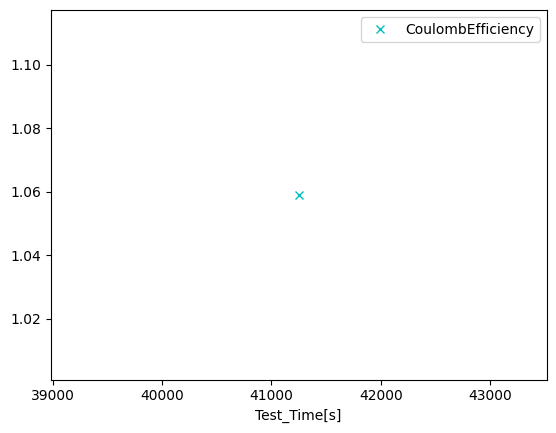

In [9]:
eet.add_efficiency_coulomb(
    df=standardized_data,
    df_blocks_charge=charge_blocks,
    df_blocks_discharge=discharge_blocks,
    config=eet.BatteryConfig.DEFAULT,
    verbose=True,
    ignore_threshold_values=True,  # TODO
).plot(x="Test_Time[s]", y="CoulombEfficiency", style="cx")